# [실습] 이변량분석(y-범주) : 직원 이직 분석

![](https://menu.moneys.co.kr/moneyweek/thumb/2024/07/30/06/2024073009254442745_4.jpg/dims/optimize/)

- 직원 이직 분석
    - 회사에서 최근 1~2년 사이 이직률이 상승하였다.
    - 여러분은, 직원들이 이직하는데 중요한 요인이 무엇인지 데이터를 기반으로 한 분석을 의뢰 받았다.

# 1.환경준비

## 1.1. 라이브러리 불러오기

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import scipy.stats as spst

## 1.2. 데이터 로딩

In [14]:
path = './../51_실습1/data/Attrition.csv'
df = pd.read_csv(path)
df.head()

,Attrition,Age,DistanceFromHome,EmployeeNumber,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,33,7,817,Male,3,Married,11691,No,11,14
1,0,35,18,1412,Male,4,Single,9362,No,11,10
2,0,42,6,1911,Male,1,Married,13348,No,13,18
3,0,46,2,1204,Female,1,Married,17048,No,23,28
4,1,22,4,593,Male,3,Single,3894,No,16,4


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Attrition          1196 non-null   int64
 1   Age                1196 non-null   int64
 2   DistanceFromHome   1196 non-null   int64
 3   EmployeeNumber     1196 non-null   int64
 4   Gender             1196 non-null   str  
 5   JobSatisfaction    1196 non-null   int64
 6   MaritalStatus      1196 non-null   str  
 7   MonthlyIncome      1196 non-null   int64
 8   OverTime           1196 non-null   str  
 9   PercentSalaryHike  1196 non-null   int64
 10  TotalWorkingYears  1196 non-null   int64
dtypes: int64(8), str(3)
memory usage: 102.9 KB


In [16]:
df.describe()

,Attrition,Age,DistanceFromHome,EmployeeNumber,JobSatisfaction,MonthlyIncome,PercentSalaryHike,TotalWorkingYears
count,1196.000000,1196.00000,1196.000000,1196.000000,1196.000000,1196.000000,1196.000000,1196.000000
mean,0.163043,36.94398,9.258361,1035.629599,2.716555,6520.104515,15.251672,11.330268
std,0.369560,9.09270,8.166016,604.340130,1.110962,4665.902253,3.625946,7.823821
min,0.000000,18.00000,1.000000,1.000000,1.000000,1009.000000,11.000000,0.000000
25%,0.000000,30.00000,2.000000,507.750000,2.000000,2928.250000,12.000000,6.000000
50%,0.000000,36.00000,7.000000,1028.000000,3.000000,4973.500000,14.000000,10.000000
75%,0.000000,43.00000,14.000000,1581.250000,4.000000,8420.500000,18.000000,15.000000
max,1.000000,60.00000,29.000000,2068.000000,4.000000,19999.000000,25.000000,40.000000


- 변수설명
    - Attrition	:	이직여부, Yes(1) , No(0) (Target)
    - Age	:	나이
    - DistanceFromHome	:	집-직장 거리(마일)
    - EmployeeNumber	:	사번
    - Gender	:	성별(Male, Female)
    - JobSatisfaction	:	직무 만족도, 다음시트 참조
    - MaritalStatus	:	결혼상태(Married, Single, Divorced)
    - MonthlyIncome	:	월급(달러)
    - OverTime	:	야근여부
    - PercentSalaryHike	:	전년대비 급여인상율(%)
    - TotalWorkingYears	:	총 근무 연수



# 2.범주-->범주

Attrition,0,1
Gender,,
Female,403,66
Male,598,129


==== coloums ====


Attrition,0,1
Gender,,
Female,0.402597,0.338462
Male,0.597403,0.661538


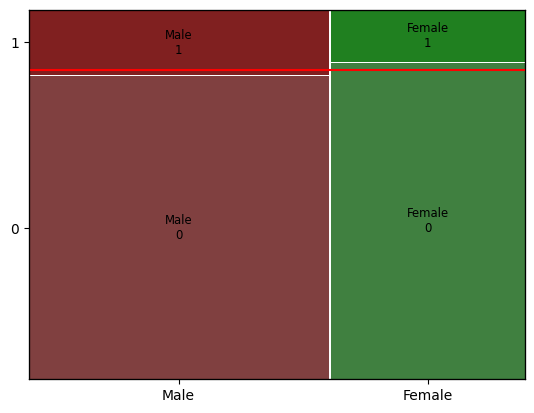

Chi2ContingencyResult(statistic=np.float64(2.5537631338119975), pvalue=np.float64(0.1100318964829815), dof=1, expected_freq=array([[392.5326087,  76.4673913],
       [608.4673913, 118.5326087]]))
==== chi2_contingency ====
statistic : 2.5537631338119975
pvalue : 0.1100318964829815
dof : 1
expected_frq : [[392.5326087  76.4673913]
 [608.4673913 118.5326087]]


In [17]:
def getAllInfo(df, x, y):
  table = pd.crosstab(df[x], df[y])
  display(table)

  print('==== coloums ====')
  table_column = pd.crosstab(df[x], df[y], normalize='columns')
  display(table_column)

  mosaic(df, [x,y])

  # 빨간선은 전체 평균을 의미
  plt.axhline(1-df[y].mean(), color='r') # 전체 사망률

  plt.show()

  statistic, pvalue, dof, expected_frq =spst.chi2_contingency(table)
  print(spst.chi2_contingency(table))


  print('==== chi2_contingency ====')

  print('statistic :', statistic)
  print('pvalue :', pvalue)
  print('dof :', dof)
  print('expected_frq :', expected_frq)

getAllInfo(df, 'Gender', 'Attrition')



## 2.1. Gender --> Attrition

1) 교차표

In [18]:
pd.crosstab(df['Gender'], df['Attrition'])

Attrition,0,1
Gender,,
Female,403,66
Male,598,129


In [19]:
pd.crosstab(df['Gender'], df['Attrition'], normalize='columns')

Attrition,0,1
Gender,,
Female,0.402597,0.338462
Male,0.597403,0.661538


2) 시각화

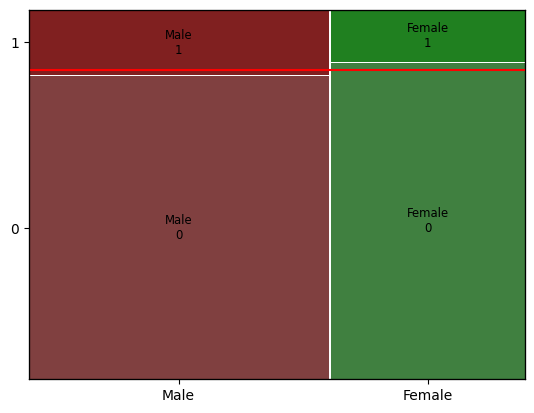

In [20]:
mosaic(df, ['Gender','Attrition'])

# 빨간선은 전체 평균을 의미
plt.axhline(1-df['Attrition'].mean(), color='r') # 전체 사망률

plt.show()

# 0은 이직 / 1을 이직No

3) 수치화 : 카이제곱검정

In [21]:
table = pd.crosstab(df['Gender'], df['Attrition'])
display(table)

spst.chi2_contingency(table)


Attrition,0,1
Gender,,
Female,403,66
Male,598,129


Chi2ContingencyResult(statistic=np.float64(2.5537631338119975), pvalue=np.float64(0.1100318964829815), dof=1, expected_freq=array([[392.5326087,  76.4673913],
       [608.4673913, 118.5326087]]))

Attrition,0,1
Gender,,
Female,403,66
Male,598,129


==== coloums ====


Attrition,0,1
Gender,,
Female,0.402597,0.338462
Male,0.597403,0.661538


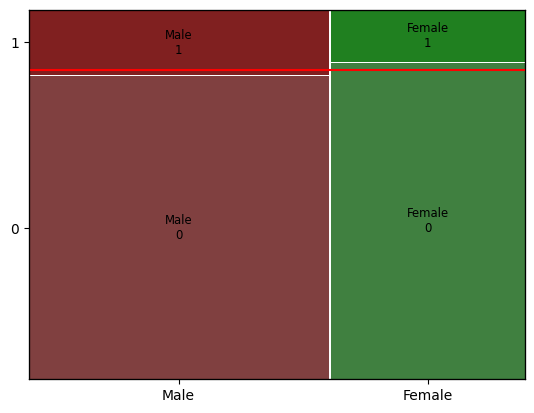

Chi2ContingencyResult(statistic=np.float64(2.5537631338119975), pvalue=np.float64(0.1100318964829815), dof=1, expected_freq=array([[392.5326087,  76.4673913],
       [608.4673913, 118.5326087]]))
==== chi2_contingency ====
statistic : 2.5537631338119975
pvalue : 0.1100318964829815
dof : 1
expected_frq : [[392.5326087  76.4673913]
 [608.4673913 118.5326087]]


In [22]:
getAllInfo(df, 'Gender', 'Attrition')

In [ ]:
# p-value가 0.110으로 0.05보다 크므로 연관성이 없다.

자유도 : 1
p-value : 0.11
카이제곱 통계량: 2.55


카이제곱 통계량:임계값이랑 비교..
2-3배 정도면 차이가 있다.



SyntaxError: illegal target for annotation (1742700607.py, line 4)

4) 파악된 내용을 기술해 봅시다.

## 2.2. JobSatisfaction --> Attrition

Attrition,0,1
JobSatisfaction,,
1,191,52
2,189,37
3,295,59
4,326,47


==== coloums ====


Attrition,0,1
JobSatisfaction,,
1,0.190809,0.266667
2,0.188811,0.189744
3,0.294705,0.302564
4,0.325674,0.241026


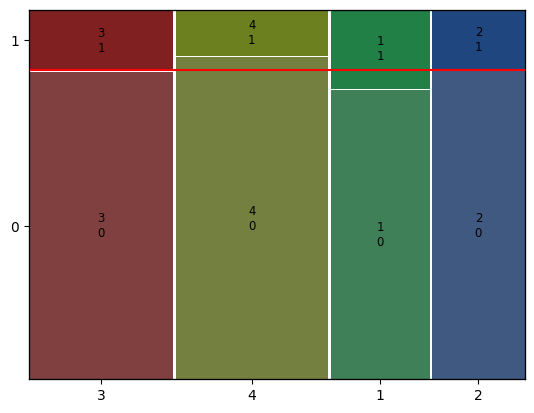

Chi2ContingencyResult(statistic=np.float64(8.40684948576828), pvalue=np.float64(0.0383107376547955), dof=3, expected_freq=array([[203.38043478,  39.61956522],
       [189.15217391,  36.84782609],
       [296.2826087 ,  57.7173913 ],
       [312.18478261,  60.81521739]]))
==== chi2_contingency ====
statistic : 8.40684948576828
pvalue : 0.0383107376547955
dof : 3
expected_frq : [[203.38043478  39.61956522]
 [189.15217391  36.84782609]
 [296.2826087   57.7173913 ]
 [312.18478261  60.81521739]]


In [ ]:
getAllInfo(df, 'JobSatisfaction', 'Attrition')

# 직무 만족도

In [ ]:
# # 직무 만족도
# 자유도: 3
# 카이제곱 통계량: 8.40
# p-value: 0.038
# 직무 만족도와 이직 여부는 통계적으로 유의한 관련이 있다

1) 교차표

2) 시각화

3) 수치화 : 카이제곱검정

4) 파악된 내용을 기술해 봅시다.

## 2.3. MaritalStatus --> Attrition

Attrition,0,1
MaritalStatus,,
Divorced,241,23
Married,479,69
Single,281,103


==== coloums ====


Attrition,0,1
MaritalStatus,,
Divorced,0.240759,0.117949
Married,0.478521,0.353846
Single,0.280719,0.528205


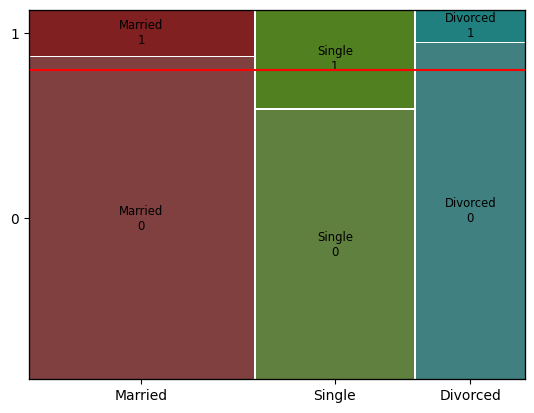

Chi2ContingencyResult(statistic=np.float64(47.82247929575401), pvalue=np.float64(4.1255377505408196e-11), dof=2, expected_freq=array([[220.95652174,  43.04347826],
       [458.65217391,  89.34782609],
       [321.39130435,  62.60869565]]))
==== chi2_contingency ====
statistic : 47.82247929575401
pvalue : 4.1255377505408196e-11
dof : 2
expected_frq : [[220.95652174  43.04347826]
 [458.65217391  89.34782609]
 [321.39130435  62.60869565]]


In [ ]:
getAllInfo(df, 'MaritalStatus', 'Attrition')

1) 교차표

In [ ]:

미혼의 이직율이 높은걸 확


In [24]:
feature = 'MaritalStatus'
target = 'Attrition'
# 이혼, 결혼
df1 = df.copy()
df1 = df1[(df1['MaritalStatus']=='Married') | (df1['MaritalStatus']=='Divorced')]
temp = pd.crosstab(df1['MaritalStatus'], df1[target], normalize='index')
temp

Attrition,0,1
MaritalStatus,,
Divorced,0.912879,0.087121
Married,0.874088,0.125912


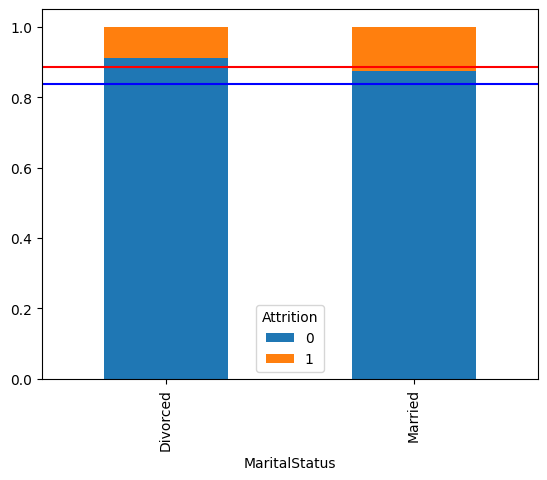

In [25]:
temp.plot.bar(stacked=True)
plt.axhline(1-df1[target].mean(), color='r')
plt.axhline(1-df[target].mean(), color='b')     # 전체 평균
plt.show()

In [26]:
# 먼저 집계
table = pd.crosstab(df1[target], df1[feature])
print('교차표\n', table)
print('-' * 100)

# 카이제곱검정
result = spst.chi2_contingency(table)
print('카이제곱통계량', result[0])
print('p-value', result[1])
print('자유도 :', result[2])
print('기대빈도\n',result[3])

교차표
 MaritalStatus  Divorced  Married
Attrition                       
0                   241      479
1                    23       69
----------------------------------------------------------------------------------------------------
카이제곱통계량 2.296463502781439
p-value 0.1296689376509814
자유도 : 1
기대빈도
 [[234.08866995 485.91133005]
 [ 29.91133005  62.08866995]]


2) 시각화

3) 수치화 : 카이제곱검정

4) 파악된 내용을 기술해 봅시다.

## 2.4. OverTime --> Attrition

Attrition,0,1
OverTime,,
No,764,90
Yes,237,105


==== coloums ====


Attrition,0,1
OverTime,,
No,0.763237,0.461538
Yes,0.236763,0.538462


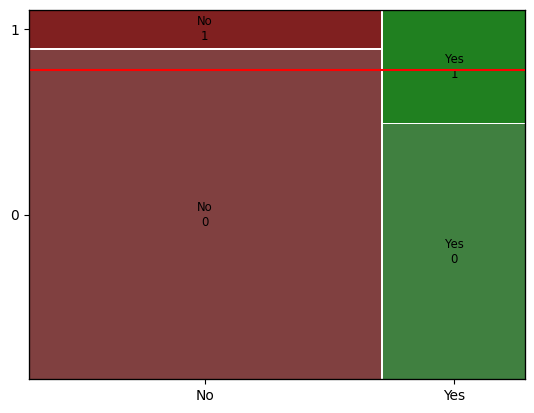

Chi2ContingencyResult(statistic=np.float64(71.28471646317081), pvalue=np.float64(3.0922183158961214e-17), dof=1, expected_freq=array([[714.76086957, 139.23913043],
       [286.23913043,  55.76086957]]))
==== chi2_contingency ====
statistic : 71.28471646317081
pvalue : 3.0922183158961214e-17
dof : 1
expected_frq : [[714.76086957 139.23913043]
 [286.23913043  55.76086957]]


In [ ]:
getAllInfo(df, 'OverTime', 'Attrition')

1) 교차표

2) 시각화

3) 수치화 : 카이제곱검정

4) 파악된 내용을 기술해 봅시다.

# 3.숫자-->범주

In [ ]:
def numGraph(df, x, y):

  sns.histplot(x=x, hue=y, data=df)

  plt.axhline(df[x].mean(), color = 'r')
  plt.show()


  sns.kdeplot(x=x, hue=y, data=df)
  # plt.axhline(df[x].mean(), color = 'r')
  plt.show()

  # sns.boxplot(x=x, y=y, data=df)

## 3.1. Age --> Attrition

1) 시각화

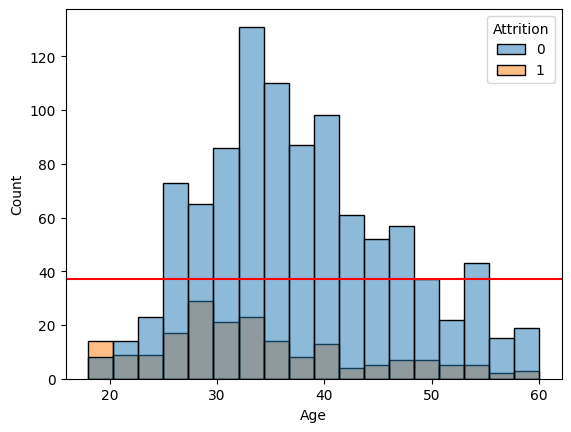

In [ ]:
sns.histplot(x='Age', hue='Attrition', data=df)
plt.axhline(df['Age'].mean(), color = 'r')
plt.show()

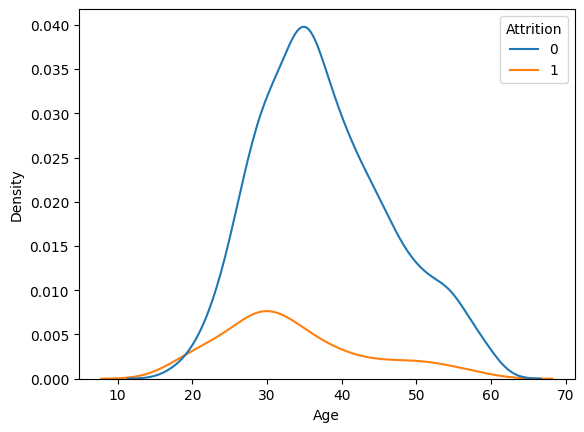

In [ ]:
# getAllInfo(df, 'Age', 'Attrition')

sns.kdeplot(x='Age', hue='Attrition', data=df)

# plt.axhline(df['Age'].mean(), color = 'r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

## 3.2. DistanceFromHome --> Attrition

1) 시각화

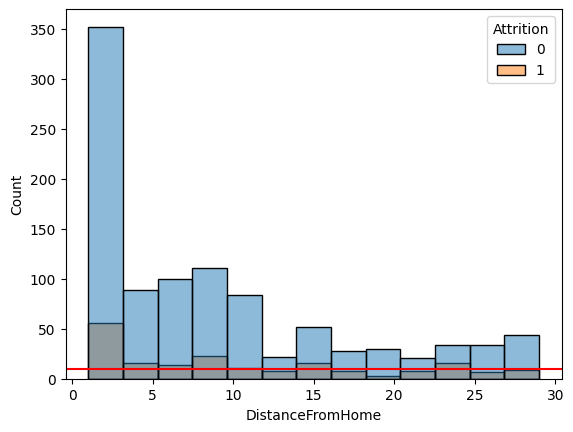

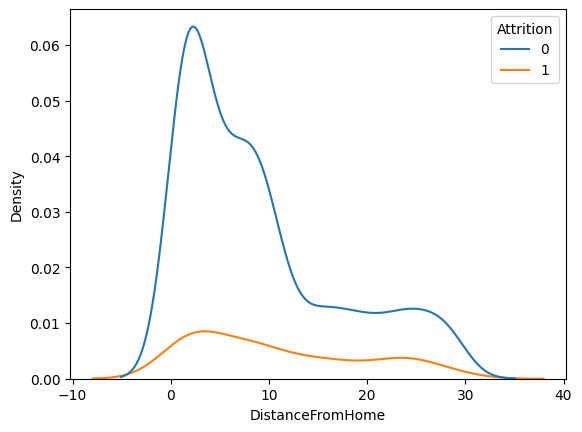

In [ ]:
numGraph(df, 'DistanceFromHome', 'Attrition')

2) 파악된 내용을 기술해 봅시다.

## 3.3. MonthlyIncome --> Attrition

1) 시각화

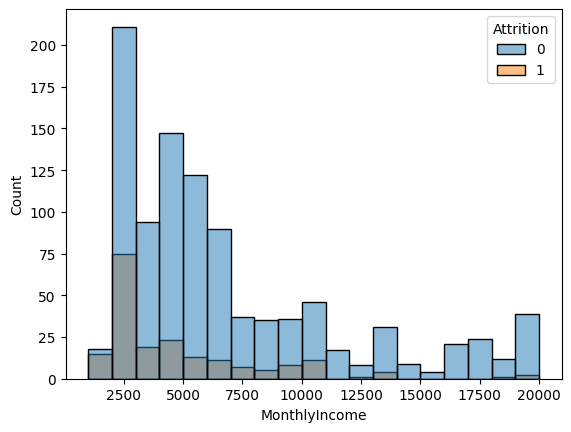

In [ ]:
# getAllInfo(df, 'MonthlyIncome', 'Attrition')
# numGraph(df,'MonthlyIncome', 'Attrition')

sns.histplot(x='MonthlyIncome', hue='Attrition', data=df)
# plt.axhline(df['Age'].mean(), color = 'r')
plt.show()

2) 파악된 내용을 기술해 봅시다.

## 3.4. PercentSalaryHike --> Attrition

1) 시각화

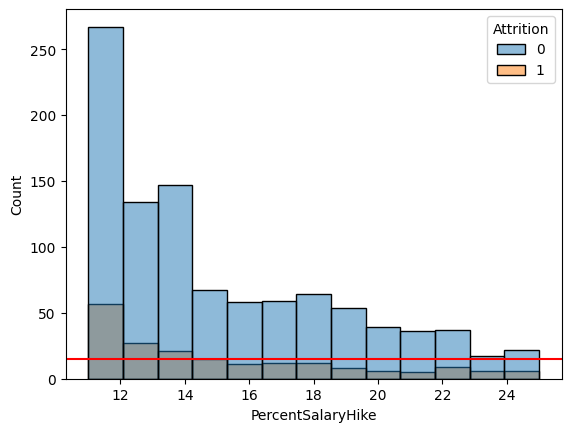

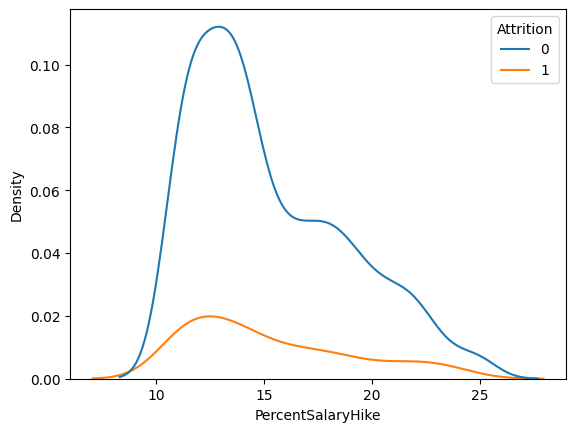

In [ ]:
numGraph(df, 'PercentSalaryHike', 'Attrition')

2) 파악된 내용을 기술해 봅시다.

## 3.5. TotalWorkingYears --> Attrition

1) 시각화

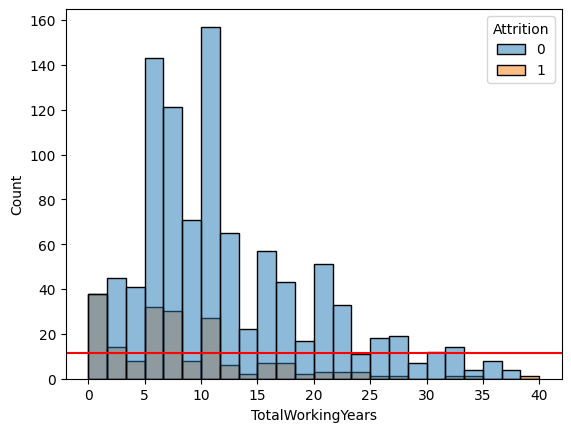

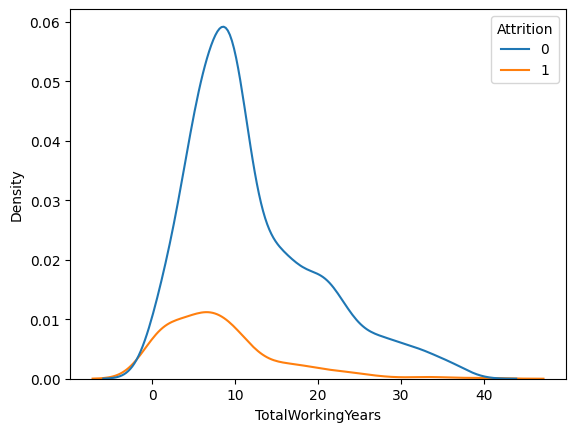

In [ ]:
numGraph(df, 'TotalWorkingYears', 'Attrition')

2) 파악된 내용을 기술해 봅시다.

# 4.관계 정리하기

① 강한관계

② 중간관계

③ 관계없음

https://docs.google.com/spreadsheets/d/1pYU5V_izE_Ai3eJlFXjSR21FHfzhsZ4hvWOsOVV9Lvc/edit?gid=172326046#gid=172326046